In [54]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from sklearn.metrics import classification_report

In [53]:
from google.colab import drive
drive.mount('/content/drive')

# List the contents of the specified directory
data_path = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon'

# Check if the directory exists before listing its contents
import os
if os.path.exists(data_path):
    print(f"Contents of {data_path}:")
    for item in os.listdir(data_path):
        print(item)
else:
    print(f"Error: The path '{data_path}' does not exist or is not accessible. Please ensure the path is correct and Google Drive is mounted properly.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Contents of /content/drive/MyDrive/AI ML/Data/FruitinAmazon:
train
test
fruit_model.keras
fruit_model_augmented.keras


Total classes found: 6
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


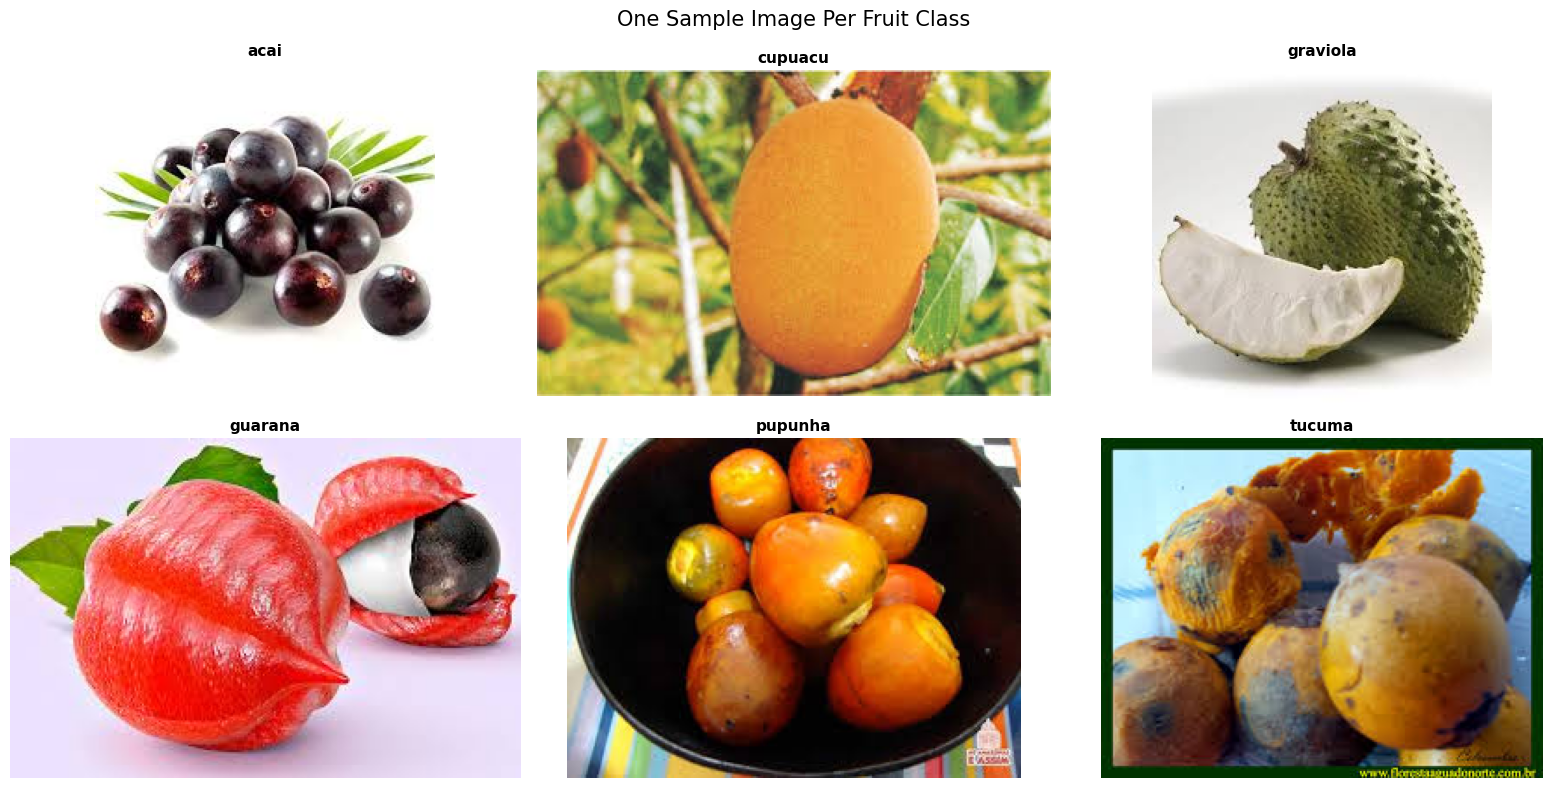

In [55]:
train_dir = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon/train'

class_dirs = sorted([
    d for d in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, d))
])

print(f"Total classes found: {len(class_dirs)}")
print("Class names:", class_dirs)


num_classes = len(class_dirs)
cols = (num_classes + 1) // 2
rows = 2

fig, axes = plt.subplots(rows, cols, figsize=(16, 8))
axes = axes.flatten()

for i, class_name in enumerate(class_dirs):
    class_path = os.path.join(train_dir, class_name)
    all_images = os.listdir(class_path)

    random_img_name = random.choice(all_images)
    img_path = os.path.join(class_path, random_img_name)

    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(class_name, fontsize=11, fontweight='bold')
    axes[i].axis('off')


for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("One Sample Image Per Fruit Class", fontsize=15)
plt.tight_layout()
plt.show()


In [56]:
corrupted_images = []   # store paths of bad images

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        try:
            img = Image.open(img_path)
            img.verify()
        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

# Final report
if len(corrupted_images) == 0:
    print(" No Corrupted Images Found.")
else:
    print(f"\n Total corrupted images removed: {len(corrupted_images)}")

 No Corrupted Images Found.


In [151]:
# Hyperparameters
IMG_HEIGHT  = 128
IMG_WIDTH   = 128
BATCH_SIZE  = 32
VAL_SPLIT   = 0.2

#Training Dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (IMG_HEIGHT, IMG_WIDTH),
    interpolation = 'nearest',
    batch_size    = BATCH_SIZE,
    shuffle       = True,
    validation_split = VAL_SPLIT,
    subset        = 'training',
    seed          = 123            # fixed seed
)

#Validation Dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels        = 'inferred',
    label_mode    = 'int',
    image_size    = (IMG_HEIGHT, IMG_WIDTH),
    interpolation = 'nearest',
    batch_size    = BATCH_SIZE,
    shuffle       = False,
    validation_split = VAL_SPLIT,
    subset        = 'validation',
    seed          = 123
)

# Get class names from the dataset
class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)
print("Number of classes:", num_classes)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [153]:
# Normalization
rescale = tf.keras.layers.Rescaling(1./255)

# .map() applies the rescaling function to every batch
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds   = val_ds.map(lambda x, y: (rescale(x), y))


AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets ready!")

Datasets ready!


In [152]:
from tensorflow.keras import layers, models


model = models.Sequential([

#conv Block 1
 layers.Conv2D(32,(3,3), padding='same', activation='relu', input_shape=(IMG_HEIGHT,IMG_WIDTH, 3)),

 #max Pooling
 #reduces spatial size by half increasing computation speed and more focus on dominant feautures
 layers.MaxPooling2D((2,2), strides = 2),


 #conv Block 2
 layers.Conv2D(32,(3,3), padding='same', activation='relu'),
 layers.MaxPooling2D((2,2), strides = 2),


 #Flattens -> Converts 3D Feature map to 1D vector
 layers.Flatten(),


 #Hidden layer 1
 layers.Dense(128, activation = 'relu'),



 #hidden layer 2

 layers.Dense(62, activation= 'relu'),


 layers.Dense(num_classes, activation='softmax')
])


# Print the architecture table
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_41 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_42 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_59 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 62)             │         7,998 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 6)              │           378 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,212,952 (16.07 MB)

 Trainable params: 4,212,952 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

In [144]:
from tensorflow.keras.optimizers import Adam
opt = Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Model Compiled")

Model Compiled


In [145]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    filepath        = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon/fruit_model.keras',
    monitor         = 'val_accuracy',
    save_best_only  = True,
    verbose         = 1
)

# Callback 2: Early Stopping
early_stop = EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 20,
    restore_best_weights = True,
    verbose              = 1
)

# Train
history = model.fit(
    train_ds,
    epochs          = 100,          # max epochs
    validation_data = val_ds,
    callbacks       = [checkpoint, early_stop],
)

print("\n Training complete!")

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step - accuracy: 0.1348 - loss: 1.8068
Epoch 1: val_accuracy improved from None to 0.72222, saving model to /content/drive/MyDrive/AI ML/Data/FruitinAmazon/fruit_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI ML/Data/FruitinAmazon/fruit_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 649ms/step - accuracy: 0.1389 - loss: 1.8038 - val_accuracy: 0.7222 - val_loss: 1.5782
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy: 0.2853 - loss: 1.7384
Epoch 2: val_accuracy did not improve from 0.72222
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 718ms/step - accuracy: 0.2778 - loss: 1.7069 - val_accuracy: 0.4444 - val_loss: 1.5628
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.3547 - loss: 1.6470
Epoch 3: val_accuracy improved from 0.72222 to 0.83333, saving model to /content/drive/MyDrive/AI ML/Data/FruitinAmazon/fruit_model.keras

Epoch 3: finished saving model to /content/drive/MyDrive/AI ML/Data/FruitinAmazon/fruit_m

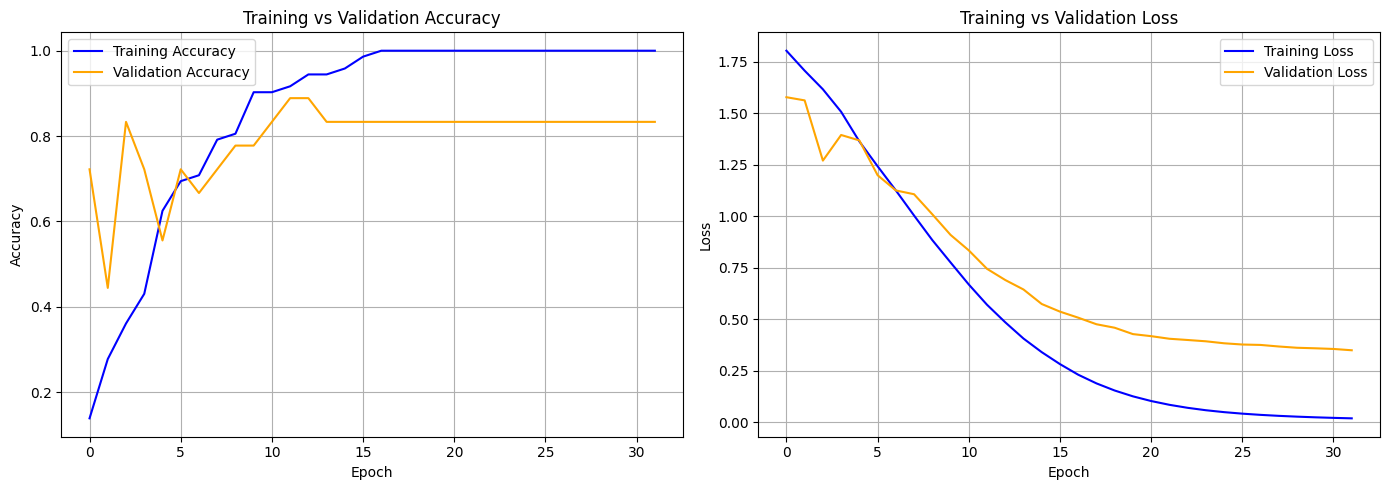

In [146]:
# history.history stores all the metrics recorded during training

acc      = history.history['accuracy']
val_acc  = history.history['val_accuracy']
loss     = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(epochs_range, acc,     label='Training Accuracy',   color='blue')
ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange')
ax1.set_title('Training vs Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(epochs_range, loss,     label='Training Loss',   color='blue')
ax2.plot(epochs_range, val_loss, label='Validation Loss', color='orange')
ax2.set_title('Training vs Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

In [147]:
# Load test dataset (separate from train)
test_dir = '/content/drive/MyDrive/AI ML/Data/FruitinAmazon/test'

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels       = 'inferred',
    label_mode   = 'int',
    image_size   = (IMG_HEIGHT, IMG_WIDTH),
    batch_size   = BATCH_SIZE,
    shuffle      = False
)

# Normalize
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Evaluate
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n Test Loss:     {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f}  ({test_acc*100:.2f}%)")

Found 30 files belonging to 6 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.6000 - loss: 1.1569

 Test Loss:     1.1569
 Test Accuracy: 0.6000  (60.00%)


In [148]:
# Save the final trained model
model.save('/content/fruit_cnn_model.h5')
print(" Model saved to /content/fruit_cnn_model.h5")

#Reload & re-evaluate
loaded_model = tf.keras.models.load_model('/content/fruit_cnn_model.h5')
print(" Model loaded successfully!")

# Re-evaluate
loss2, acc2 = loaded_model.evaluate(test_ds, verbose=1)
print(f"\n Loaded Model — Test Accuracy: {acc2*100:.2f}%")

 Model saved to /content/fruit_cnn_model.h5
 Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step - accuracy: 0.6000 - loss: 1.1569

 Loaded Model — Test Accuracy: 60.00%


In [149]:
# Get all true labels and predicted labels from test set

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Print classification report
print("\n Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


 Classification Report:

              precision    recall  f1-score   support

        acai       0.62      1.00      0.77         5
     cupuacu       0.50      0.40      0.44         5
    graviola       0.50      0.80      0.62         5
     guarana       0.67      0.40      0.50         5
     pupunha       0.80      0.80      0.80         5
      tucuma       0.50      0.20      0.29         5

    accuracy                           0.60        30
   macro avg       0.60      0.60      0.57        30
weighted avg       0.60      0.60      0.57        30



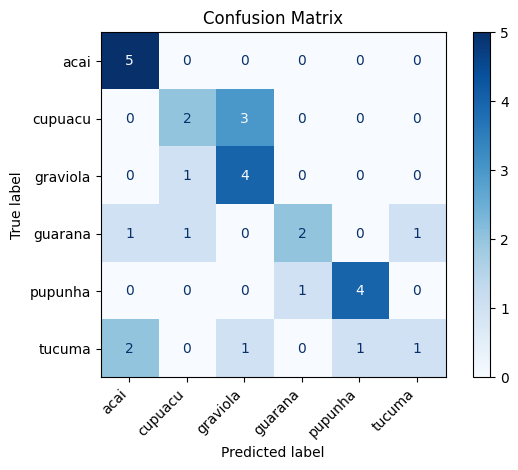

In [150]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()